In [12]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
attacking_data = pd.read_csv("worldcup_2026_team_attacking_stats.csv").drop("Rank", axis=1)
defensive_data = pd.read_csv("worldcup_2026_team_defensive_stats.csv").drop("Rank", axis=1)
movement_data = pd.read_csv("worldcup_2026_team_offers_receptions_stats.csv").drop("Rank", axis=1)
passing_data = pd.read_csv("worldcup_2026_team_passing_stats.csv").drop("Rank", axis=1)
physical_data = pd.read_csv("worldcup_2026_team_physical_stats.csv").drop("Rank", axis=1)


In [14]:
merged_data = (
    attacking_data
    .merge(defensive_data, on="Team")
    .merge(movement_data, on="Team")
    .merge(passing_data, on="Team")
    .merge(physical_data, on="Team")
)


In [15]:
merged_data["xG efficiency"] = pd.to_numeric(
    merged_data["xG efficiency"].astype(str).str.replace(r"[^0-9.]", "", regex=True),
    errors="coerce"
)
if "xG efficiency" in merged_data.columns:
    merged_data = merged_data.drop("xG efficiency", axis=1)


In [16]:
merged_data.map(lambda x: isinstance(x,str)).sum()

Team                                              48
Goals                                              0
Assists                                            0
Attempts at goal                                   0
Attempts on target                                 0
Attempts off target                                0
Attempt at goal conversion rate                    0
Attempts inside the penalty area                   0
Attempts outside the penalty area                  0
Headed attempts at goal                            0
xG                                                 0
Corners                                            0
Possession control                                 0
Own goals                                          0
Goals conceded                                     0
Forced turnovers                                   0
Ball recovery time                                 0
Defensive pressures applied                        0
Defensive pressures directly applied          

In [17]:
teams_percentiles=merged_data
teams_percentiles_features=teams_percentiles.drop(['Team',],axis=1)

In [18]:
percentiles=teams_percentiles_features.rank(pct=True)*100

In [19]:
percentiles.iloc[3].sort_values(ascending=True)

Goals conceded                                      3.125000
Crossing accuracy                                  21.875000
Own goals                                          38.541667
Attempt at goal conversion rate                    39.583333
Average Speed                                      65.625000
Ball recovery time                                 87.500000
Defensive pressures directly applied               89.583333
Assists                                            89.583333
Goals                                              92.708333
Passing accuracy                                   94.791667
Switches of play accuracy                          94.791667
Defensive pressures applied                        95.833333
Take-ons completed                                 95.833333
Headed attempts at goal                            96.875000
Attempts inside the penalty area                   97.916667
Receptions in behind                               97.916667
Defensive line breaks at

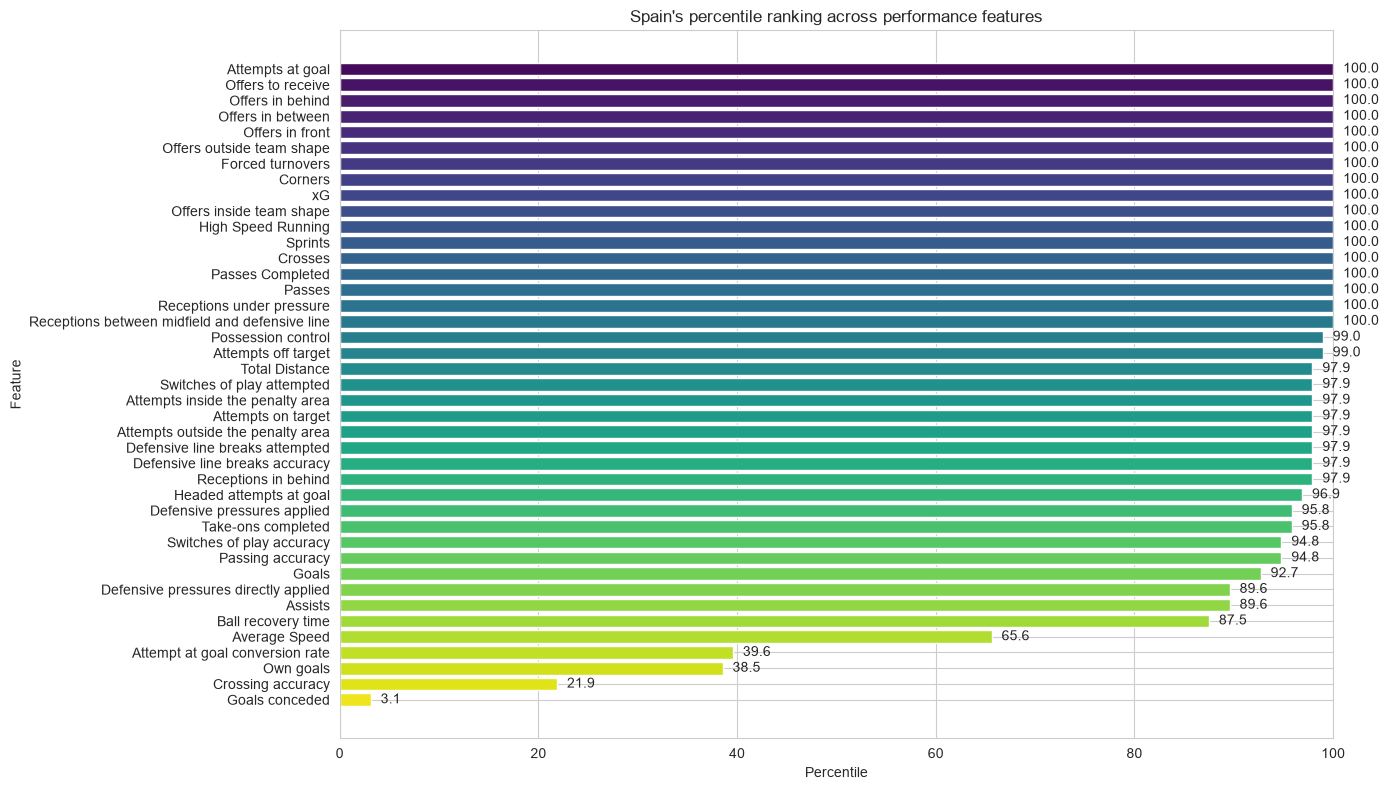

In [20]:
sns.set_style("whitegrid")

ranked_percentiles = percentiles.loc[3].sort_values(ascending=False)

plt.figure(figsize=(14, 8))
bars = plt.barh(
    ranked_percentiles.index,
    ranked_percentiles.values,
    color=sns.color_palette("viridis", len(ranked_percentiles))
)
plt.gca().invert_yaxis()
plt.xlabel("Percentile")
plt.ylabel("Feature")
plt.title("Spain's percentile ranking across performance features")
plt.xlim(0, 100)

for bar, value in zip(bars, ranked_percentiles.values):
    plt.text(value + 1, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", va="center", ha="left")

plt.tight_layout()
plt.show()

Spain better than 80 percent in almozt all my metrics except average speed,attempt at goal conversion rate and crossing accuracy that all .No much weakeness expected by the worlcup winners 

In [ ]:
# Calculate the most efficient Attack (Teams scoring much more than expected are either:)
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()

merged_data['Attack Efficiency']=merged_data['Goals']/merged_data['xG']


merged_data['Attack Efficiency'] = scalar.fit_transform(merged_data[['Attack Efficiency']])
merged_data['Attack Efficiency']=merged_data['Attack Efficiency']*100
efficiency_attack=merged_data[['Team', 'Attack Efficiency']].sort_values(by='Attack Efficiency', ascending=False)



"merged_data['Attack Efficiency'] = scalar.fit_transform(merged_data[['Attack Efficiency']])\nmerged_data['Attack Efficiency']=merged_data['Attack Efficiency']*100\nefficiency_attack=merged_data[['Team', 'Attack Efficiency']].sort_values(by='Attack Efficiency', ascending=False)\n"

In [ ]:
efficiency_attack.head(10)
# The Top 5 Teams with the most Efficient Attack 
#Spain,France and Argentina are not part of the top 10 Teams with the most efficient Attack and they have
#One of the best attackers in the world

,Team,Attack Efficiency
17,Japan,100.000000
21,Bosnia and Herzegovina,97.120098
8,Netherlands,87.175000
36,Tunisia,70.758929
20,Croatia,69.721408
6,USA,68.426217
26,New Zealand,63.911290
33,Jordan,63.569519
27,Cabo Verde,61.914063
19,Austria,61.275773


In [76]:
merged_data.columns

Index(['Team', 'Goals', 'Assists', 'Attempts at goal', 'Attempts on target',
       'Attempts off target', 'Attempt at goal conversion rate',
       'Attempts inside the penalty area', 'Attempts outside the penalty area',
       'Headed attempts at goal', 'xG', 'Corners', 'Possession control',
       'Own goals', 'Goals conceded', 'Forced turnovers', 'Ball recovery time',
       'Defensive pressures applied', 'Defensive pressures directly applied',
       'Offers to receive', 'Offers in behind', 'Offers in between',
       'Offers in front', 'Offers inside team shape',
       'Offers outside team shape', 'Receptions in behind',
       'Receptions between midfield and defensive line',
       'Receptions under pressure', 'Passes', 'Passes Completed',
       'Passing accuracy', 'Crosses', 'Crossing accuracy',
       'Take-ons completed', 'Defensive line breaks attempted',
       'Defensive line breaks accuracy', 'Switches of play attempted',
       'Switches of play accuracy', 'Average Sp

(0.0, 100.0)

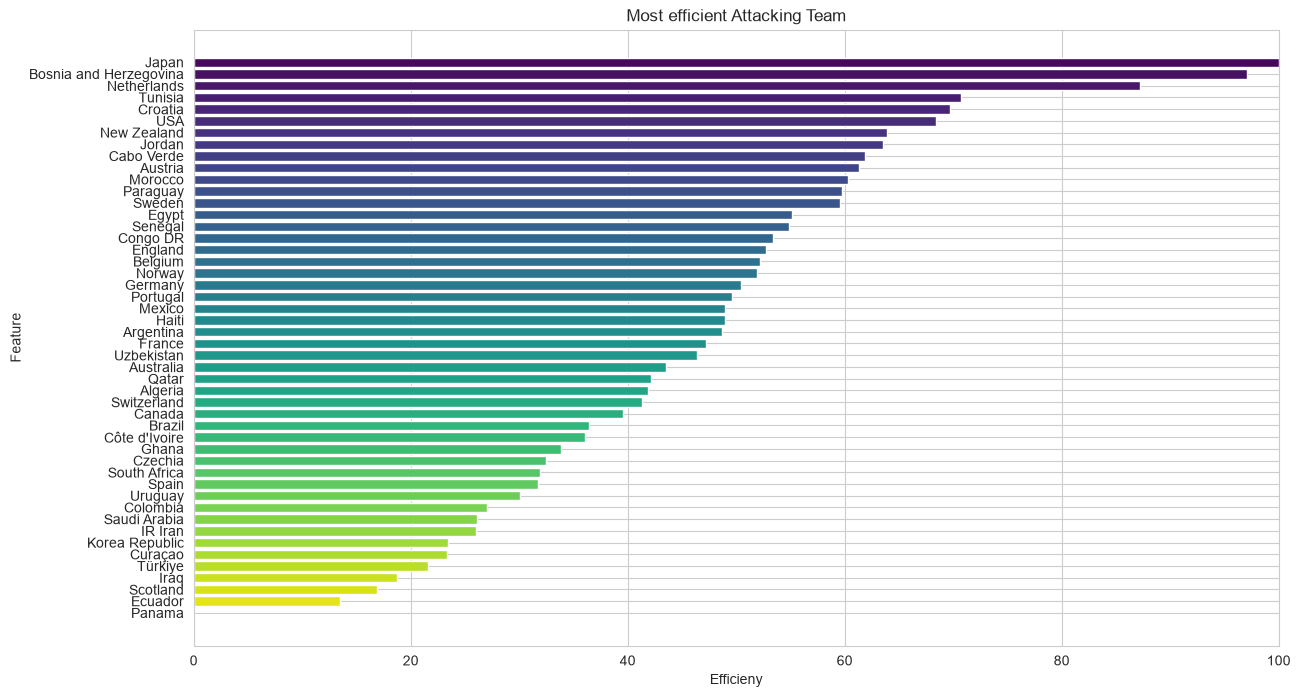

In [55]:
plt.figure(figsize=(14, 8))
bars = plt.barh(
    efficiency_attack["Team"],
    efficiency_attack["Attack Efficiency"],
    color=sns.color_palette("viridis", len(efficiency_attack))
)
plt.gca().invert_yaxis()
plt.xlabel("Efficieny")
plt.ylabel("Feature")
plt.title("Most efficient Attacking Team")
plt.xlim(0, 100)

Shocking is that Japan Had the most Efficient Attack .They where scoring much more than expected 
Japan was Very clinical and Benefiting from unsustainable finishing more than any country in the tournament